- orbital area: eye area 
- nose bulge: nose area
- cheek bulge: cheek area
- ear position: ear area
- whisker change: side bart area

## Task Description
- Why I use DLC?
    - First I mark the muzzle area by myself, then I train DLC, so that DLC can mark muzzle area for me. At end I can use the marked muzzle area to crop image.

- How do you want to train DLC?
   - there are 4 kinds of mice, each mouse has different number of images. and only 3500 images are labeled.
   - I plan to first filter out those labeled images.
   - Then I want to group images by mice type.
   - Then I want to use same proportion of images. E.g. if there are 80% of brown mice in total, then I also wish to have 80% brown mice in my human marked images for DLC to train.
   - I plan to only mark the eye-left, eye-right and nose-tip area of mice. Because with this triangle area, I can already crop a rectangle muzzle area.

The file 00_full_image_classification.ipynb is what I already coded. Now I want to do the following thing.

ToDo:  
The images are stored in the path mouse_dataset/images.  
E.g. the image 000001.jpg can be found unter path mouse_dataset/images/000001.jpg.  

The file MouseGrimaceFaces_main.csv can be found unter path mouse_dataset/MouseGrimaceFaces_main.csv.  
The file MouseGrimaceFaces_mgs.csv can be found unter path mouse_dataset/MouseGrimaceFaces_mgs.csv.

Since there are around 35000 images but only around 3500 images are labeled with mgs score. I wish to filter out those images which has mgs score, and store those images unter the path mouse_dataset/images_mgs/   

if the mgs score is 9 or NA, or value missing, it means it is not usable. I don't need such images.



Question: if mgs is a mix of 0,1,2 and 9, should I keep it or remove it???

In [ ]:
print("hello")

In [1]:
from pathlib import Path
import shutil
import pandas as pd

# -------------------------
# Paths
# -------------------------
DATASET_DIR = Path("mouse_dataset")

IMAGE_DIR = DATASET_DIR / "images"
MGS_CSV = DATASET_DIR / "MouseGrimaceFaces_mgs.csv"
OUTPUT_DIR = DATASET_DIR / "images_mgs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Load MGS csv
# -------------------------
mgs_df = pd.read_csv(MGS_CSV)

print("Original MGS rows:", len(mgs_df))
print(mgs_df.head())

# -------------------------
# Score columns
# -------------------------
# columns like ot1, nb1, cb1, ep1, wc1, ...
score_cols = [
    col for col in mgs_df.columns
    if col not in ["index", "subset"]
]

# Convert scores to numeric:
# valid scores: 0, 1, 2
# invalid: 9
# missing/no score: "-", NaN, empty cells
scores = mgs_df[score_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# -------------------------
# Filter usable images
# 至少有一个有效分数(0,1,2)，不能出现 9
# -------------------------
# Condition 1: at least one valid score 0/1/2 
has_valid_score = scores.isin([0, 1, 2]).any(axis=1)

# Condition 2: no score equals 9
has_no_9 = ~scores.eq(9).any(axis=1)

usable_df = mgs_df[has_valid_score & has_no_9].copy()

print("Usable MGS rows:", len(usable_df))
print("Removed rows:", len(mgs_df) - len(usable_df))

# -------------------------
# Copy usable images
# -------------------------
copied = 0
missing_files = []

for filename in usable_df["index"]:
    src = IMAGE_DIR / filename
    dst = OUTPUT_DIR / filename

    if src.exists():
        shutil.copy2(src, dst)
        copied += 1
    else:
        missing_files.append(filename)

print("Copied images:", copied)
print("Missing image files:", len(missing_files))

if missing_files:
    print("First missing files:")
    print(missing_files[:10])

# Optional: save list of usable images
usable_csv_path = DATASET_DIR / "usable_mgs_images.csv"
usable_df.to_csv(usable_csv_path, index=False)

print("Saved usable image list to:", usable_csv_path)
print("Copied images stored under:", OUTPUT_DIR)

Original MGS rows: 3406
        index  ot1  nb1  cb1  ep1  wc1 ot2 nb2 cb2 ep2  ... nb11 cb11 ep11  \
0  000008.jpg    -    -    -    -    -   -   -   -   -  ...    1    0    0   
1  000009.jpg    1    1    0    1    2   0   0   0   0  ...    -    -    -   
2  000015.jpg  NaN  NaN  NaN  NaN  NaN   -   -   -   -  ...  NaN  NaN  NaN   
3  000027.jpg  NaN  NaN  NaN  NaN  NaN   1   1   1   1  ...  NaN  NaN  NaN   
4  000031.jpg    -    -    -    -    -   -   -   -   -  ...    1    0    0   

  wc11 ot12 nb12 cb12 ep12 wc12 subset  
0    0    0    1    0    1    1     KH  
1    -    -    -    -    -    -     KH  
2  NaN  NaN  NaN  NaN  NaN  NaN     JW  
3  NaN  NaN  NaN  NaN  NaN  NaN     JW  
4    0    0    1    1    1    1     KH  

[5 rows x 57 columns]
Usable MGS rows: 2163
Removed rows: 1243
Copied images: 2163
Missing image files: 0
Saved usable image list to: mouse_dataset/usable_mgs_images.csv
Copied images stored under: mouse_dataset/images_mgs


## DLC Training
Now you need to select images and train DLC.  
There are 2163 usable images.  
I plan to mark 250 images by myself and try out the effect.  
I plan to use those body parts. 
- nose
- eye_left
- eye_right

- conda activate DEEPLABCUT  
- python -m deeplabcut


apply training result on our images

In [ ]:
import deeplabcut

config_path = "mouse-mgs-2026-06-04/config.yaml"

deeplabcut.analyze_time_lapse_frames(
    config_path,
    directory="mouse_dataset/images_mgs",
    frametype=".jpg",
    save_as_csv=True
)

read the h5 file of DLC after the step above

In [9]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
from tqdm import tqdm

dlc_h5_path = Path(
    "mouse_dataset/images_mgs/image_predictions_DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200.h5"
)

image_dir = Path("mouse_dataset/images_mgs")
output_dir = Path("mouse_dataset/muzzle_crops")
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_hdf(dlc_h5_path)

scorer = df.columns.get_level_values("scorer")[0]
individual = df.columns.get_level_values("individuals")[0]

print("scorer:", scorer)
print("individual:", individual)
print("bodyparts:", df.columns.get_level_values("bodyparts").unique().tolist())

scorer: DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200
individual: animal
bodyparts: ['nose', 'left_eye', 'right_eye']


In [10]:
print(df.columns)

MultiIndex([('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...),
            ('DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200', ...)],
           names=['scorer', 'individuals', 'bodyparts', 'coords'])


In [11]:
scorer = df.columns.get_level_values(0)[0]

bodyparts = df.columns.get_level_values(1).unique()
print("scorer:", scorer)
print("bodyparts:")
for bp in bodyparts:
    print(bp)

scorer: DLC_Resnet50_mouseJun4shuffle1_snapshot_best-200
bodyparts:
animal


must nose, left_eye, right_eye 3 points all > PCUTOFF

In [5]:
NOSE = "nose-tip"
EYE_L = "left_eye"
EYE_R = "right_eye"

In [13]:
from PIL import Image
import numpy as np
from tqdm import tqdm
import os

# ====== 你需要检查这里 ======
image_dir = Path("mouse_dataset/images_mgs")
output_dir = Path("mouse_dataset/muzzle_crops")
output_dir.mkdir(parents=True, exist_ok=True)

NOSE = "nose"
EYE_L = "left_eye"
EYE_R = "right_eye"

PCUTOFF = 0.5
BOX_SCALE = 3.0
MIN_BOX_SIZE = 80

def get_point(row, bodypart):
    x = row[(scorer, individual, bodypart, "x")]
    y = row[(scorer, individual, bodypart, "y")]
    p = row[(scorer, individual, bodypart, "likelihood")]
    return float(x), float(y), float(p)

saved = 0
skipped_not_in_dlc = 0
skipped_low_confidence = 0

for image_path in tqdm(sorted(image_dir.glob("*"))):
    if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    # 关键修改：用完整路径，而不是 image_path.name
    dlc_index = str(image_path)

    if dlc_index not in df.index:
        skipped_not_in_dlc += 1
        continue

    row = df.loc[dlc_index]

    nose_x, nose_y, nose_p = get_point(row, NOSE)
    eye_l_x, eye_l_y, eye_l_p = get_point(row, EYE_L)
    eye_r_x, eye_r_y, eye_r_p = get_point(row, EYE_R)

    if min(nose_p, eye_l_p, eye_r_p) < PCUTOFF:
        skipped_low_confidence += 1
        continue

    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    eye_dist = np.sqrt((eye_l_x - eye_r_x) ** 2 + (eye_l_y - eye_r_y) ** 2)
    box_size = max(eye_dist * BOX_SCALE, MIN_BOX_SIZE)

    center_x = nose_x
    center_y = nose_y

    x1 = int(center_x - box_size / 2)
    x2 = int(center_x + box_size / 2)
    y1 = int(center_y - box_size / 2)
    y2 = int(center_y + box_size / 2)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    crop = img.crop((x1, y1, x2, y2))
    crop = crop.resize((224, 224))

    crop.save(output_dir / image_path.name)

    saved += 1

print("Saved crops:", saved)
print("Skipped because not in DLC index:", skipped_not_in_dlc)
print("Skipped because low confidence:", skipped_low_confidence)

100%|██████████| 2165/2165 [00:03<00:00, 550.92it/s]

Saved crops: 541
Skipped because not in DLC index: 0
Skipped because low confidence: 1622


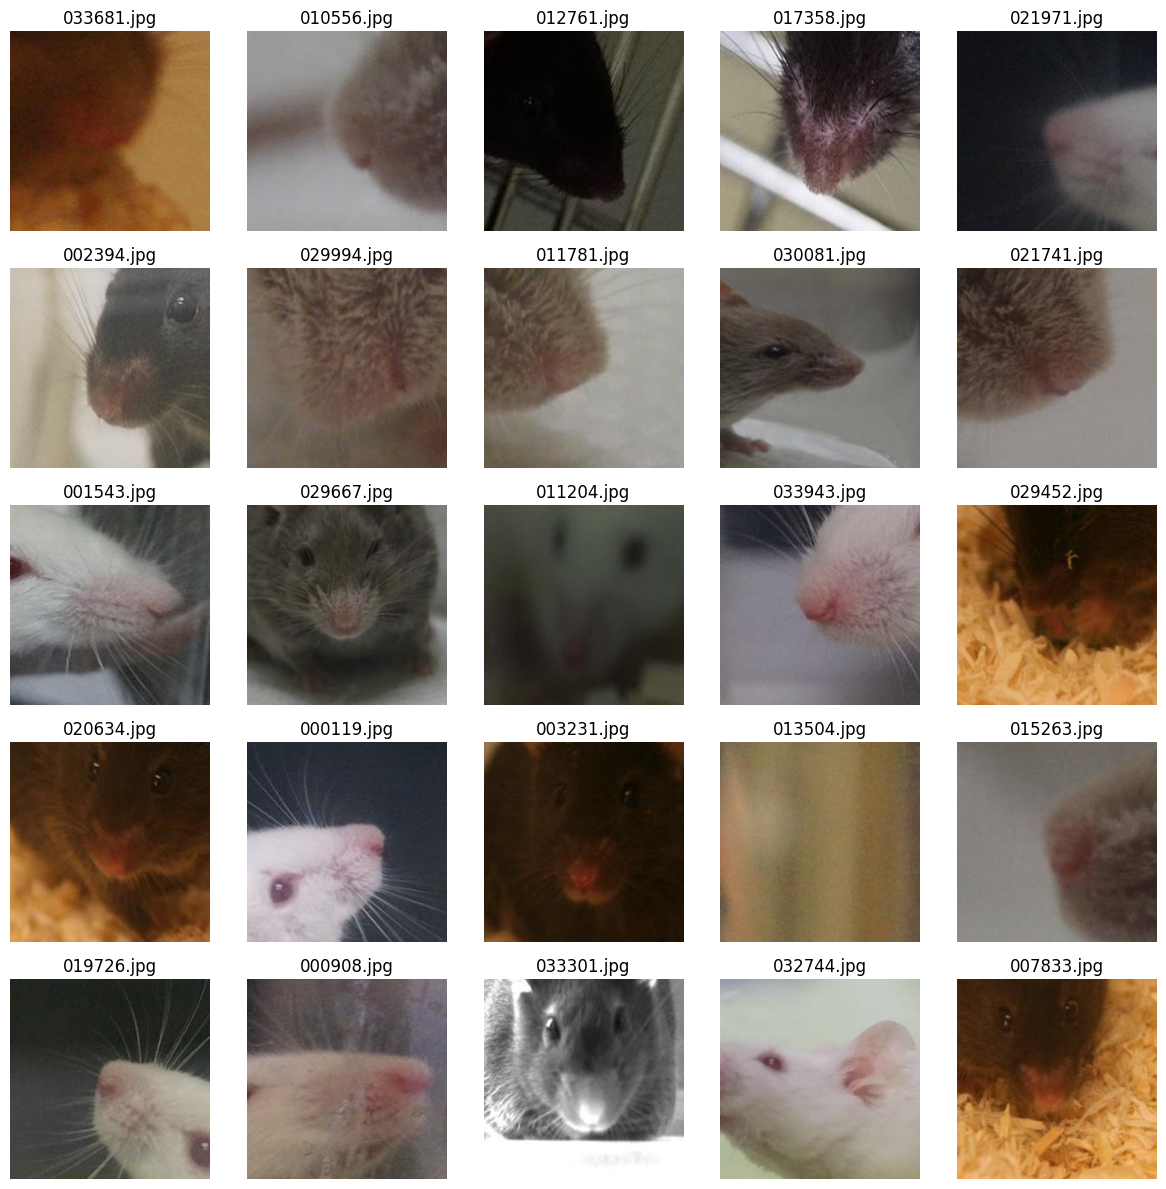

In [19]:
import matplotlib.pyplot as plt
import random

crop_paths = list(output_dir.glob("*"))

sample_paths = random.sample(crop_paths, min(25, len(crop_paths)))

plt.figure(figsize=(12, 12))

for i, path in enumerate(sample_paths):
    img = Image.open(path)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.name[:10])

plt.tight_layout()
plt.show()

nose + at least one eye 

In [16]:
NOSE = "nose"
EYE_L = "left_eye"
EYE_R = "right_eye"

PCUTOFF_NOSE = 0.5
PCUTOFF_EYE = 0.3
BOX_SIZE = 180

saved = 0
skipped_not_in_dlc = 0
skipped_low_confidence = 0

for image_path in tqdm(sorted(image_dir.glob("*"))):
    if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    dlc_index = str(image_path)

    if dlc_index not in df.index:
        skipped_not_in_dlc += 1
        continue

    row = df.loc[dlc_index]

    nose_x, nose_y, nose_p = get_point(row, NOSE)
    eye_l_x, eye_l_y, eye_l_p = get_point(row, EYE_L)
    eye_r_x, eye_r_y, eye_r_p = get_point(row, EYE_R)

    # 只要求 nose 可靠
    if nose_p < PCUTOFF_NOSE:
        skipped_low_confidence += 1
        continue

    # 检查 nose 坐标是否正常
    if not np.isfinite([nose_x, nose_y]).all():
        skipped_low_confidence += 1
        continue

    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    if eye_l_p >= PCUTOFF_EYE and eye_r_p >= PCUTOFF_EYE:
        eye_dist = np.sqrt((eye_l_x - eye_r_x) ** 2 + (eye_l_y - eye_r_y) ** 2)
        box_size = max(eye_dist * 3.0, 100)
    else:
        box_size = BOX_SIZE

    if not np.isfinite(box_size) or box_size <= 0:
        skipped_low_confidence += 1
        continue

    center_x = nose_x
    center_y = nose_y

    x1 = int(center_x - box_size / 2)
    x2 = int(center_x + box_size / 2)
    y1 = int(center_y - box_size / 2)
    y2 = int(center_y + box_size / 2)

    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(W, x2)
    y2 = min(H, y2)

    if x2 <= x1 or y2 <= y1:
        skipped_low_confidence += 1
        continue

    crop = img.crop((x1, y1, x2, y2))
    crop = crop.resize((224, 224))
    crop.save(output_dir / image_path.name)
    saved += 1

print("Saved crops:", saved)
print("Skipped because not in DLC index:", skipped_not_in_dlc)
print("Skipped because low confidence:", skipped_low_confidence)

100%|██████████| 2165/2165 [00:09<00:00, 232.29it/s]

Saved crops: 1592
Skipped because not in DLC index: 0
Skipped because low confidence: 571


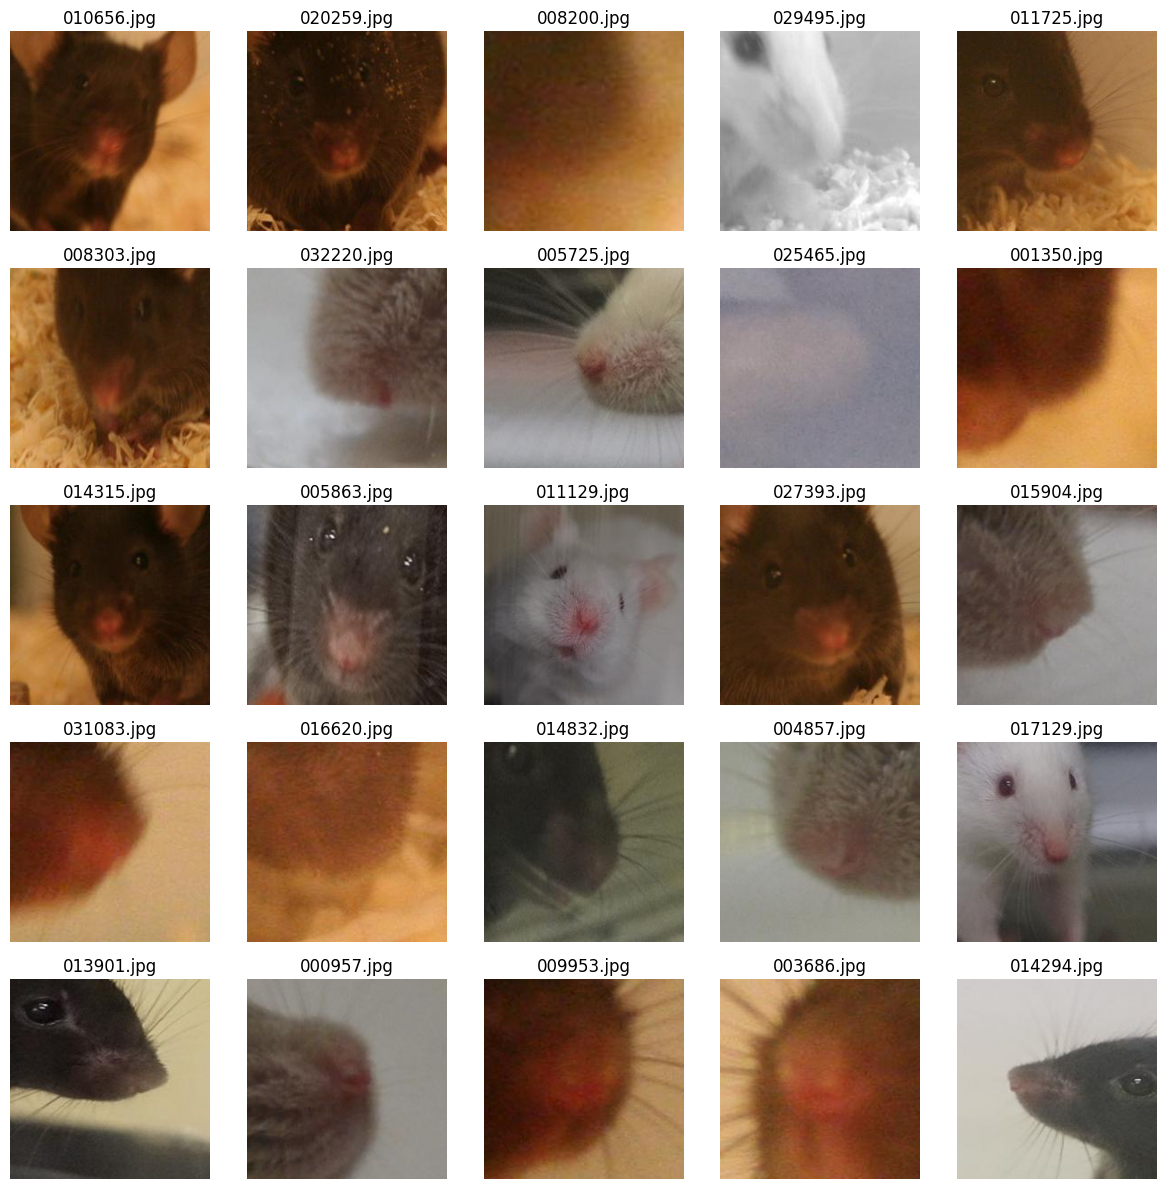

In [17]:
import matplotlib.pyplot as plt
import random

crop_paths = list(output_dir.glob("*"))

sample_paths = random.sample(crop_paths, min(25, len(crop_paths)))

plt.figure(figsize=(12, 12))

for i, path in enumerate(sample_paths):
    img = Image.open(path)
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.name[:10])

plt.tight_layout()
plt.show()